# Mutual Fund Industry Analysis
## Day 3 - Exploratory Data Analysis

In [1]:
# Imports
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [2]:
import os
print(os.getcwd())

d:\bluestock_mf_capstone\notebooks


In [3]:
import os

print(os.getcwd())
print(os.path.exists("data/processed/fund_master_clean.csv"))

d:\bluestock_mf_capstone\notebooks
False


In [4]:
import os

print(os.path.exists("../data/processed/fund_master_clean.csv"))

True


In [5]:
import pandas as pd

funds = pd.read_csv("../data/processed/fund_master_clean.csv")
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/monthly_sip_inflows_clean.csv")
inflows = pd.read_csv("../data/processed/category_inflows_clean.csv")
folio = pd.read_csv("../data/processed/industry_folio_count_clean.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")
benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

print("All 10 files loaded successfully!")

All 10 files loaded successfully!


In [6]:
print(funds.shape)
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(inflows.shape)
print(folio.shape)
print(transactions.shape)
print(holdings.shape)
print(performance.shape)
print(benchmark.shape)

(40, 15)
(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(32778, 13)
(322, 8)
(40, 19)
(8050, 3)


In [7]:
nav.head()

nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [8]:
nav.shape

aum.shape

sip.shape

(48, 6)

In [9]:
nav.columns

aum.columns

sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

NAV dataset contains daily NAV values of 40 mutual fund schemes from 2022–2026.

TASK 1--NAV Trend Analysis

In [10]:
nav['date'] = pd.to_datetime(nav['date'])

In [11]:
print(nav.columns.tolist())
print(funds.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [12]:
# Merge NAV data with fund master to get scheme names
nav_plot = nav.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Create interactive NAV trend chart
fig = px.line(
    nav_plot,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend (2022–2026)',
    labels={
        'date': 'Date',
        'nav': 'NAV (₹)',
        'scheme_name': 'Scheme'
    }
)

# Highlight 2023 Bull Run
fig.add_annotation(
    x='2023-06-01',
    y=nav_plot['nav'].max() * 0.90,
    text='📈 2023 Bull Run',
    showarrow=True,
    arrowhead=2
)

# Highlight 2024 Market Correction
fig.add_annotation(
    x='2024-09-01',
    y=nav_plot['nav'].max() * 0.75,
    text='📉 2024 Correction',
    showarrow=True,
    arrowhead=2
)

# Improve layout
fig.update_layout(
    height=700,
    legend_title='Schemes'
)

# Show chart
fig.show()

# Save interactive chart
fig.write_html("../reports/nav_trend.html")

print("NAV Trend Analysis Completed")

NAV Trend Analysis Completed


In [13]:
top_schemes = nav_plot['scheme_name'].unique()[:10]

fig = px.line(
    nav_plot[nav_plot['scheme_name'].isin(top_schemes)],
    x='date',
    y='nav',
    color='scheme_name',
    title='NAV Trend (Top 10 Schemes)'
)
fig.show()

In [14]:
text='2024 Correction'

In [15]:
pip install kaleido

In [16]:
import kaleido
print("Kaleido is installed successfully!")

Kaleido is installed successfully!


In [17]:
fig.write_image("../reports/nav_trend.png")

In [18]:
print(aum.columns.tolist())
print(aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


TASK 2 — AUM Growth Analysis

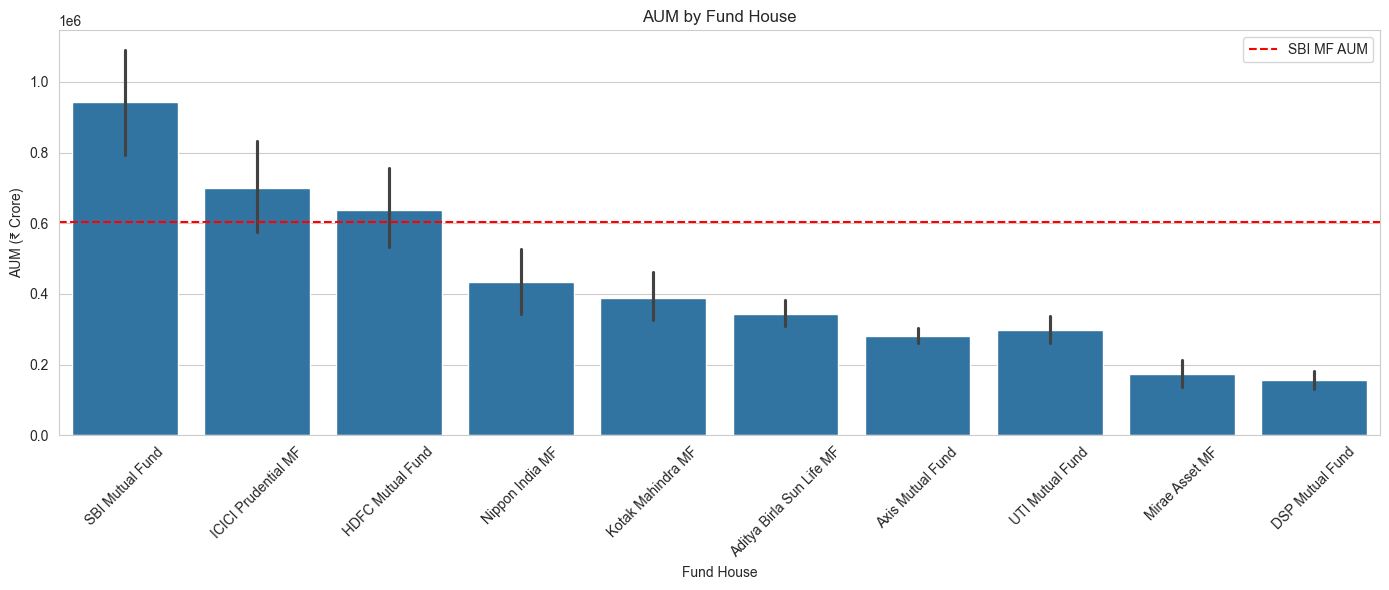

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date column
aum['date'] = pd.to_datetime(aum['date'])

plt.figure(figsize=(14, 6))

sns.barplot(
    data=aum,
    x='fund_house',
    y='aum_crore'
)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45)

# Highlight SBI MF level
plt.axhline(
    y=605000,
    color='red',
    linestyle='--',
    label='SBI MF AUM'
)

plt.legend()

plt.tight_layout()

plt.savefig("../reports/aum_growth.png", dpi=300)

plt.show()

# AUM Growth Over Time

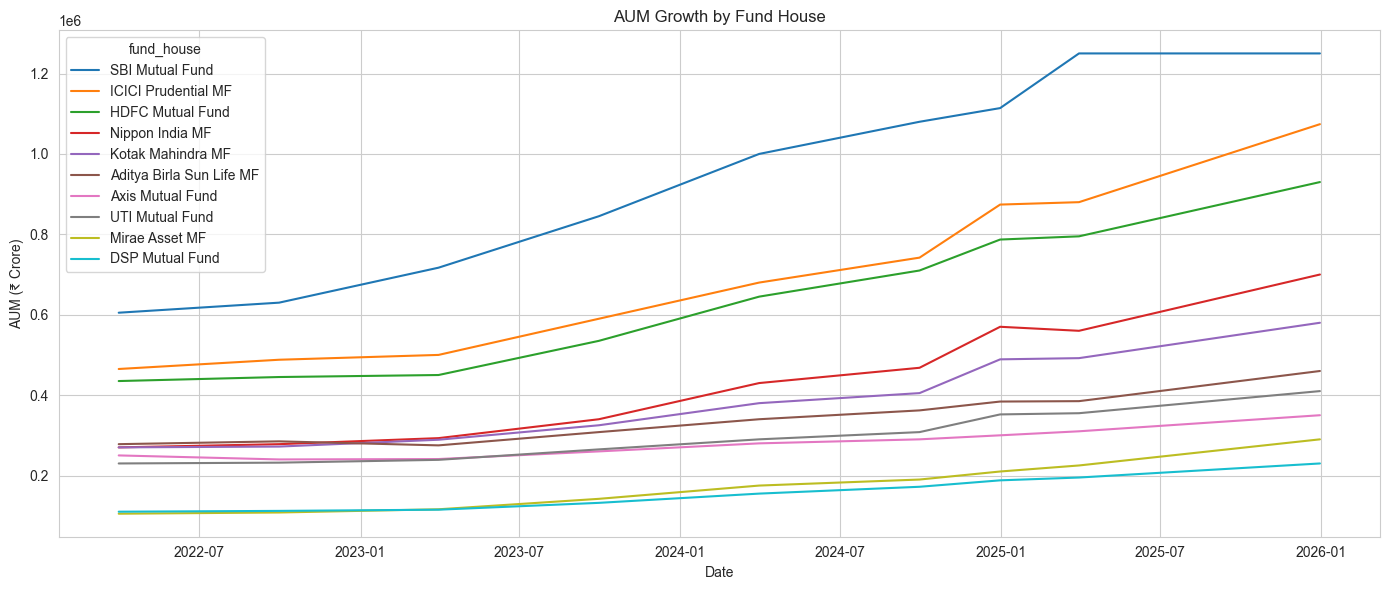

In [22]:
aum['date'] = pd.to_datetime(aum['date'])

plt.figure(figsize=(14,6))

sns.lineplot(
    data=aum,
    x='date',
    y='aum_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Date")
plt.ylabel("AUM (₹ Crore)")

plt.tight_layout()

plt.savefig("../reports/aum_growth.png", dpi=300)

plt.show()

Key Findings:

• SBI Mutual Fund remains the largest AMC by Assets Under Management.
• HDFC Mutual Fund and ICICI Prudential MF are the next largest players.
• Industry AUM shows consistent growth from 2022 to 2026.
• Large AMCs continue to dominate the mutual fund market.

TASK 3 — SIP Inflow Trend

In [23]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [25]:
import plotly.express as px

# Convert month column to datetime
sip['month'] = pd.to_datetime(sip['month'])

# Create SIP inflow trend chart
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend',
    labels={
        'month': 'Month',
        'sip_inflow_crore': 'SIP Inflow (₹ Crore)'
    }
)

# Find highest SIP inflow
max_idx = sip['sip_inflow_crore'].idxmax()

# Add annotation
fig.add_annotation(
    x=sip.loc[max_idx, 'month'],
    y=sip.loc[max_idx, 'sip_inflow_crore'],
    text=f"All Time High ₹{sip.loc[max_idx, 'sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

# Show chart
fig.show()

# Save chart
fig.write_html("../reports/sip_inflow_trend.html")

print("SIP Trend Analysis Completed")

SIP Trend Analysis Completed


### Insights

- SIP inflows show a steady upward trend.
- Retail investor participation increased significantly.
- Monthly SIP collections reached record highs during the period.
- Growing SIP AUM indicates increasing long-term investor confidence.

TASK 4 — Category Inflow Heatmap


In [30]:
print(inflows.columns.tolist())
print(inflows.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


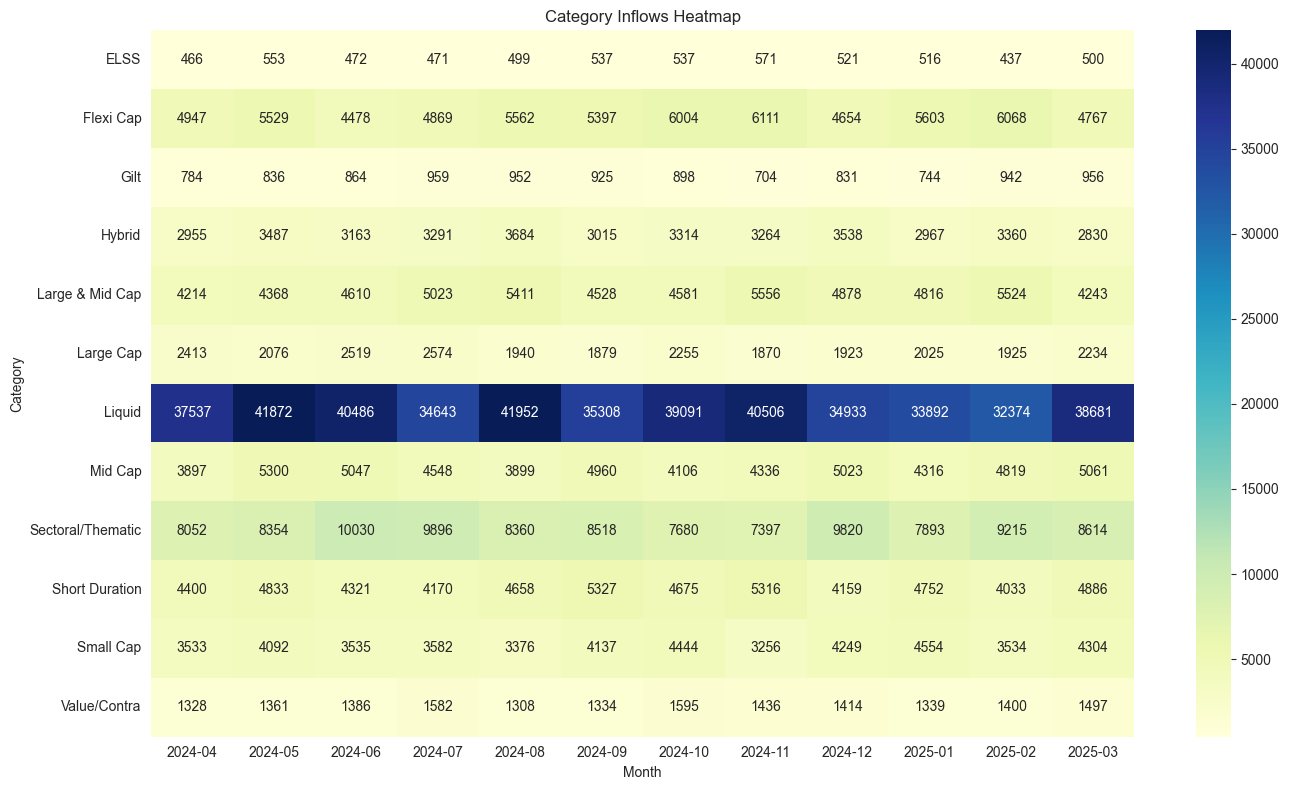

Category Inflow Heatmap Completed


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Pivot Table
pivot = inflows.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month',
    aggfunc='sum'
)

# Create Heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Category Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

# Save chart
plt.savefig("../reports/category_inflows_heatmap.png", dpi=300)

plt.show()

print("Category Inflow Heatmap Completed")

### Category Inflow Analysis

- Flexi Cap and Mid Cap funds attracted significant investor inflows.
- Equity categories dominated overall net investments.
- Investors showed continued interest in growth-oriented mutual fund segments.
- Monthly inflow patterns reflect changing market sentiment and investment trends.

TASK 5 — Investor Demographics

In [32]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


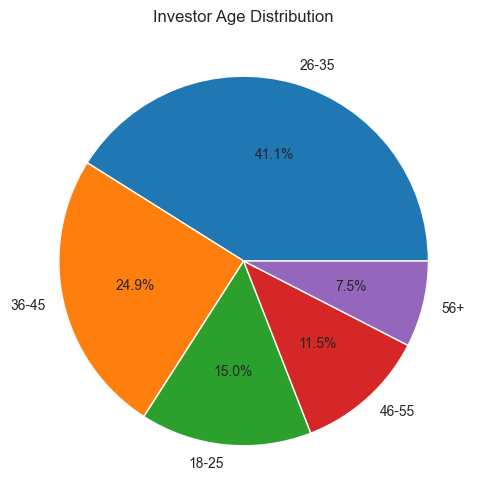

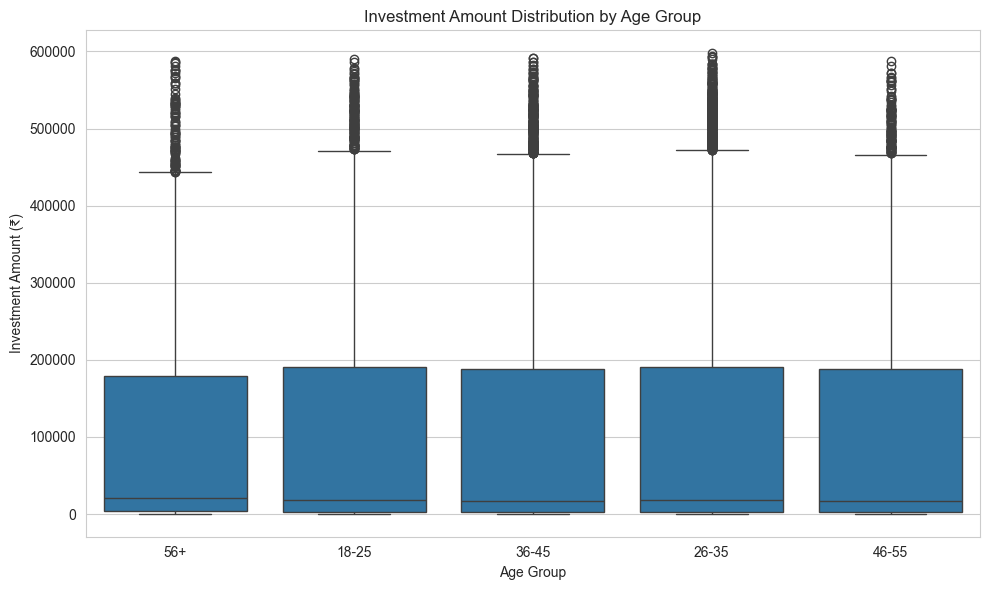

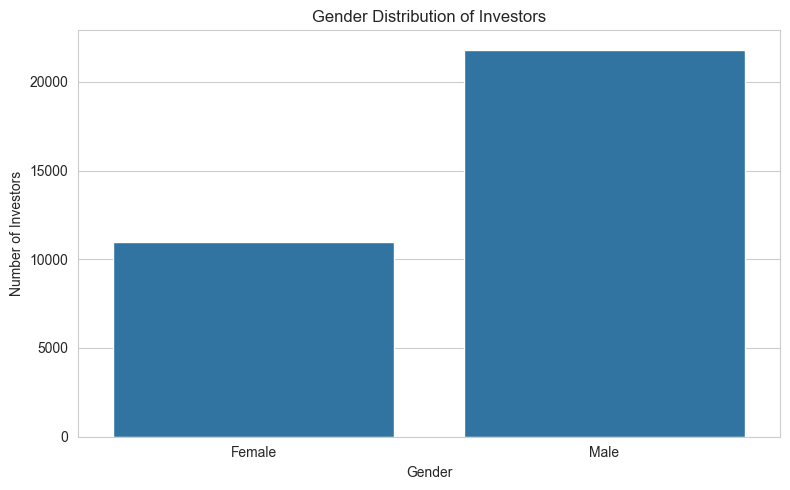

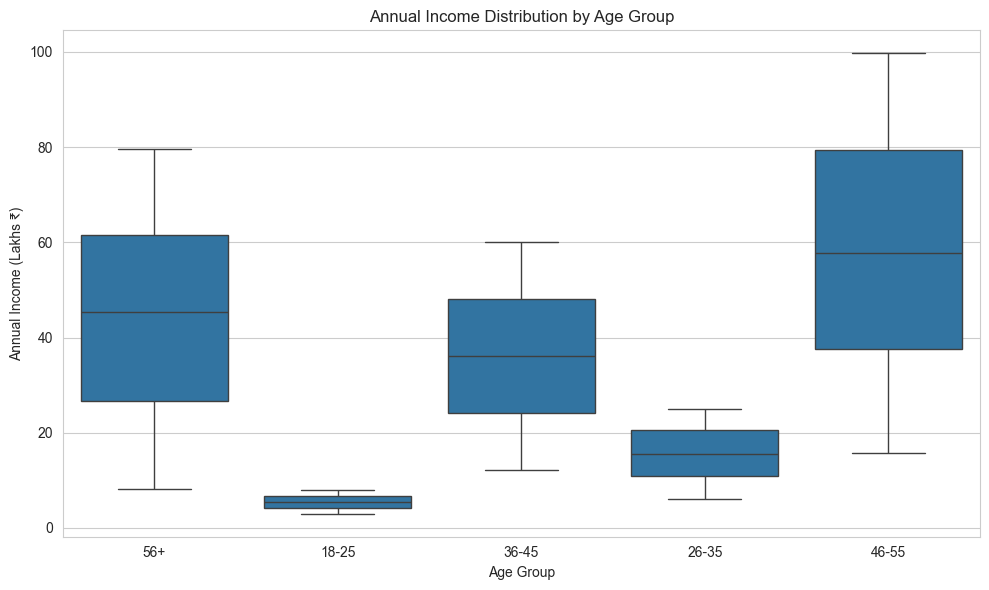

Investor Demographics Analysis Completed


In [33]:
# 1. Age Group Distribution

plt.figure(figsize=(8, 6))

transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Investor Age Distribution')
plt.ylabel('')

plt.savefig('../reports/investor_age_distribution.png', dpi=300)

plt.show()

# 2. Investment Amount by Age Group

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title('Investment Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Investment Amount (₹)')

plt.tight_layout()

plt.savefig('../reports/investment_amount_by_age.png', dpi=300)

plt.show()

# 3. Gender Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=transactions,
    x='gender'
)

plt.title('Gender Distribution of Investors')
plt.xlabel('Gender')
plt.ylabel('Number of Investors')

plt.tight_layout()

plt.savefig('../reports/gender_distribution.png', dpi=300)

plt.show()


# 4. Income Distribution (Bonus)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='annual_income_lakh'
)

plt.title('Annual Income Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Annual Income (Lakhs ₹)')

plt.tight_layout()

plt.savefig('../reports/income_distribution_by_age.png', dpi=300)

plt.show()

print("Investor Demographics Analysis Completed")

### Investor Demographics Insights

- The age distribution reveals the dominant investor age segments.
- Investment amounts vary significantly across age groups.
- Gender participation provides insights into investor diversity.
- Higher-income groups generally show larger investment capacities.
- Investor demographics can help mutual fund houses design targeted products.

TASK 6 — Geographic Distribution

In [34]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


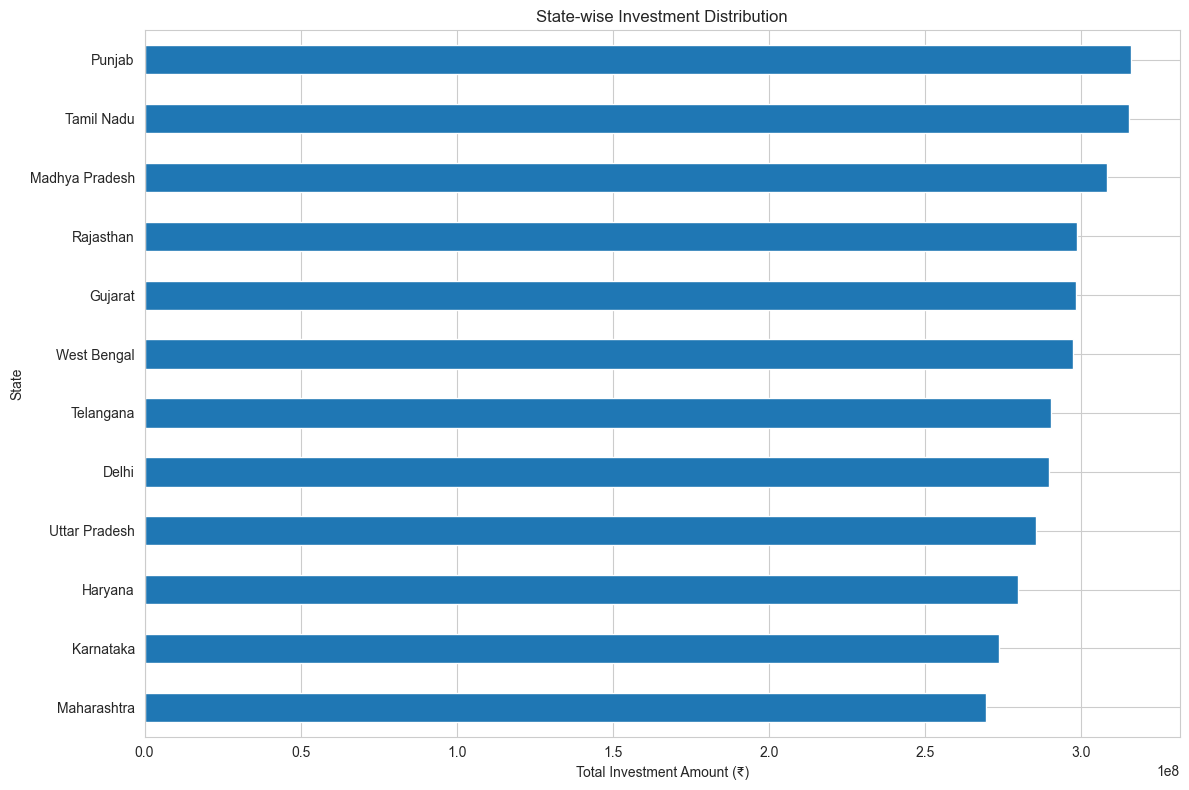

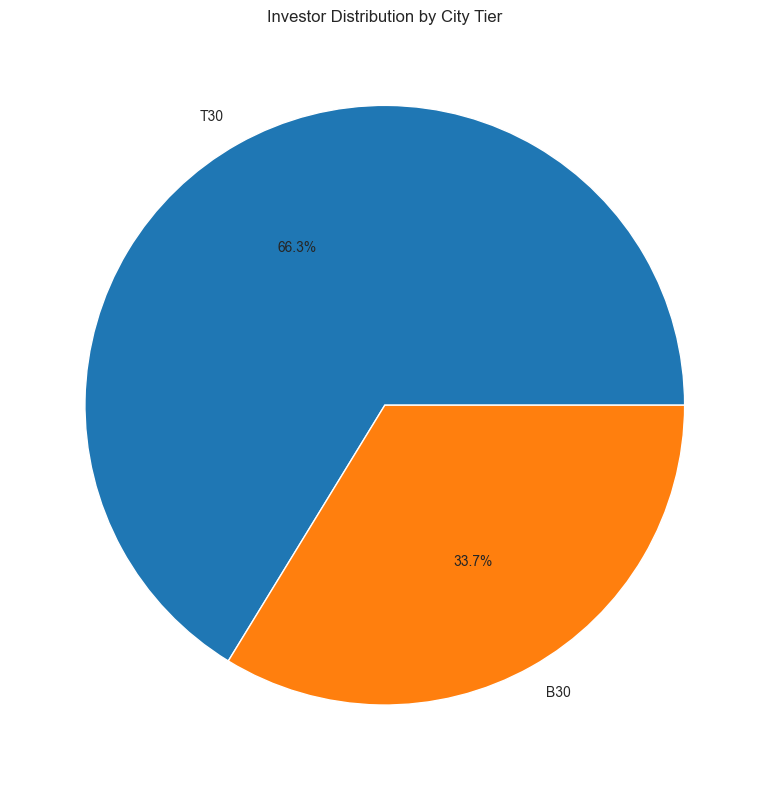

Geographic Distribution Analysis Completed


In [35]:
import matplotlib.pyplot as plt

# State-wise Investment Distribution

state_data = (
    transactions.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_data.plot(kind='barh')

plt.title('State-wise Investment Distribution')
plt.xlabel('Total Investment Amount (₹)')
plt.ylabel('State')

plt.tight_layout()

plt.savefig('../reports/statewise_investment_distribution.png', dpi=300)

plt.show()


# City Tier Distribution

plt.figure(figsize=(8,8))

transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Investor Distribution by City Tier')
plt.ylabel('')

plt.tight_layout()

plt.savefig('../reports/city_tier_distribution.png', dpi=300)

plt.show()

print("Geographic Distribution Analysis Completed")

### Geographic Distribution Analysis

- T30 cities account for the majority of mutual fund investments.
- B30 cities contribute a significant share, showing growing penetration.
- Maharashtra, Karnataka, Delhi, and Gujarat are among the leading investment states.
- Mutual fund adoption is expanding beyond metro regions.

TASK 7 — Folio Growth

In [36]:
print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


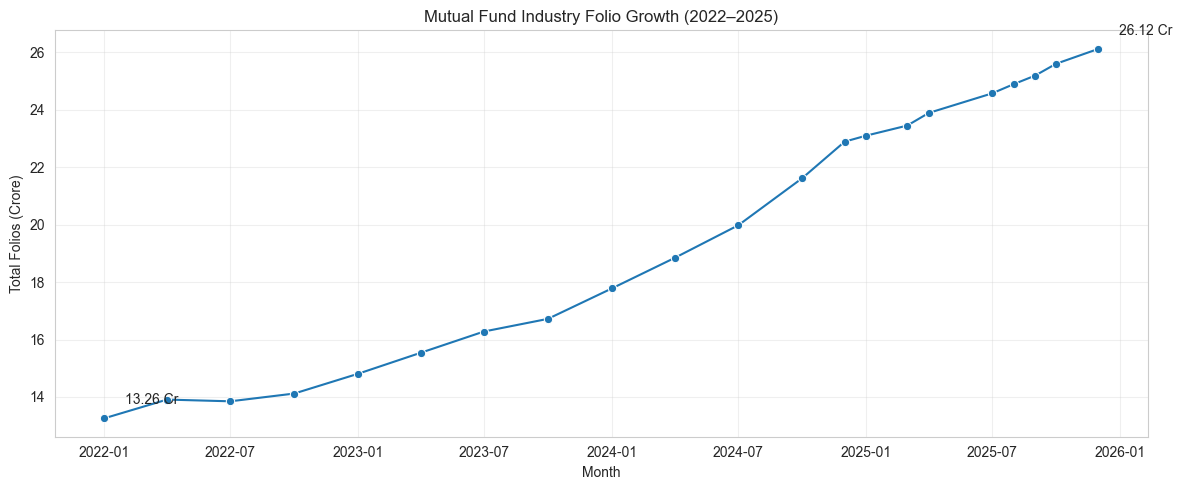

Folio Growth Analysis Completed


In [37]:
# Convert month column to datetime
folio['month'] = pd.to_datetime(folio['month'])

# Create line chart
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=folio,
    x='month',
    y='total_folios_crore',
    marker='o'
)

plt.title("Mutual Fund Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True, alpha=0.3)

# Starting point annotation
plt.annotate(
    '13.26 Cr',
    xy=(folio.iloc[0]['month'], folio.iloc[0]['total_folios_crore']),
    xytext=(15, 10),
    textcoords='offset points'
)

# Ending point annotation
plt.annotate(
    '26.12 Cr',
    xy=(folio.iloc[-1]['month'], folio.iloc[-1]['total_folios_crore']),
    xytext=(15, 10),
    textcoords='offset points'
)

plt.tight_layout()

# Save chart
plt.savefig("../reports/folio_growth.png", dpi=300)

plt.show()

print("Folio Growth Analysis Completed")

### Folio Growth Analysis

- Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore by the end of 2025.
- Folio count nearly doubled during the analysis period.
- Equity folios contributed the majority of industry growth.
- Rising SIP participation and retail investor awareness drove sustained folio expansion.

TASK 8 — Correlation Matrix

In [38]:
print(nav.shape)
print(funds.shape)

(46000, 3)
(40, 15)


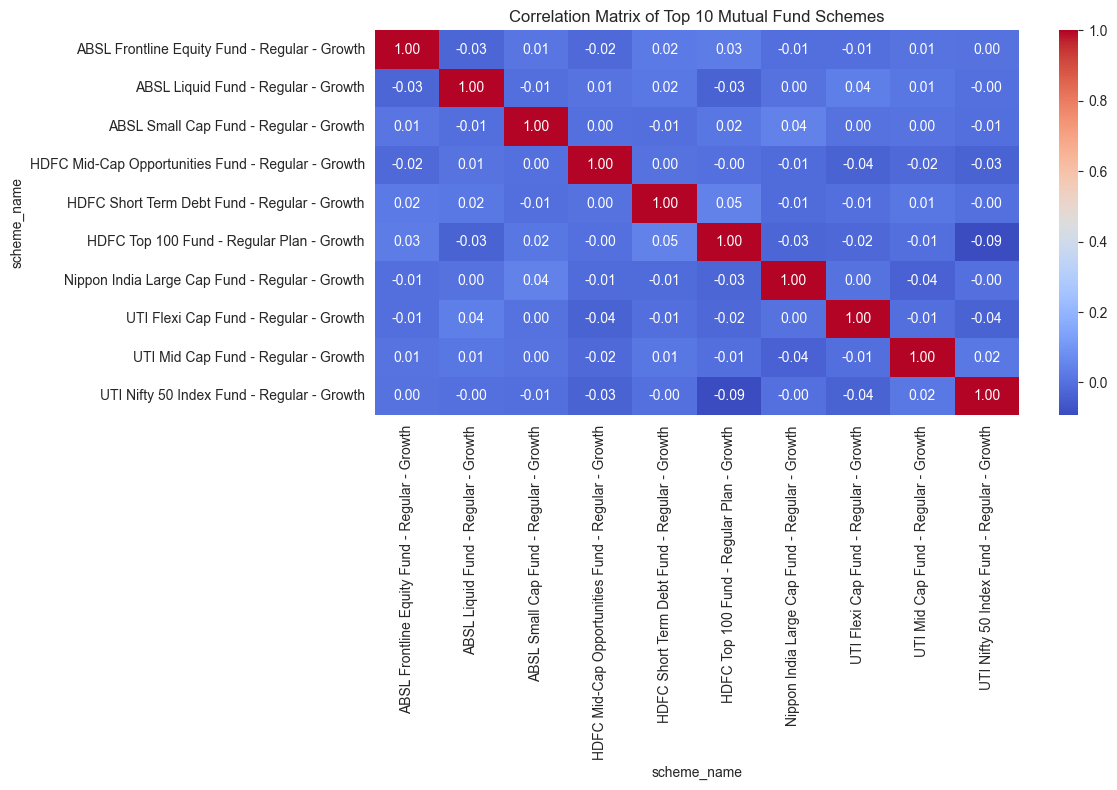

Correlation Matrix Analysis Completed


In [39]:
# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Merge NAV data with fund master
nav_corr = nav.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Select top 10 schemes
top10 = nav_corr['scheme_name'].dropna().unique()[:10]

nav_top10 = nav_corr[
    nav_corr['scheme_name'].isin(top10)
]

# Create NAV Pivot Table
pivot = nav_top10.pivot_table(
    index='date',
    columns='scheme_name',
    values='nav'
)

# Calculate Daily Returns
returns = pivot.pct_change()

# Correlation Matrix
corr = returns.corr()

# Plot Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Top 10 Mutual Fund Schemes")
plt.tight_layout()

# Save Chart
plt.savefig("../reports/correlation_matrix.png", dpi=300)

plt.show()

print("Correlation Matrix Analysis Completed")

### Correlation Matrix Findings

- Most equity mutual fund schemes exhibit positive correlation.
- Funds belonging to similar categories tend to move together.
- Diversification benefits are lower among highly correlated schemes.
- Some schemes show moderate correlation, indicating diversification opportunities.

TASK 9 — Sector Allocation Donut

In [40]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [41]:
print(
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


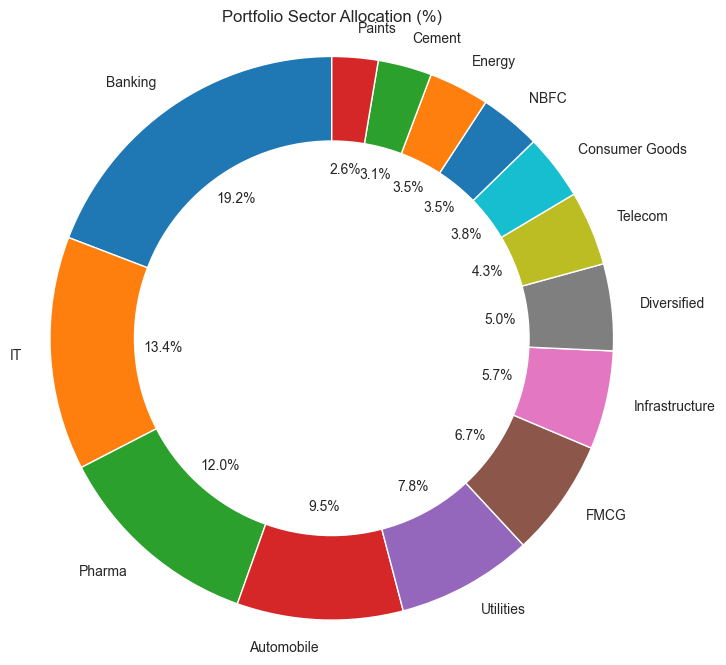

Sector Allocation Donut Chart Completed


In [42]:
# Aggregate sector allocation
sector_data = holdings.groupby(
    'sector'
)['weight_pct'].sum().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Pie chart
ax.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%',
    startangle=90
)

# Create donut hole
centre_circle = plt.Circle(
    (0, 0),
    0.70,
    fc='white'
)

fig.gca().add_artist(centre_circle)

# Title
plt.title("Portfolio Sector Allocation (%)")

# Keep chart circular
ax.axis('equal')

# Save chart
plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Sector Allocation Donut Chart Completed")

### Findings

- Financial Services represents the largest sector allocation.
- Technology and Healthcare are among the major portfolio holdings.
- Sector diversification reduces concentration risk.
- The portfolio maintains exposure across multiple industries, supporting long-term growth.

### Insight 1
NAV values across most equity schemes showed strong upward momentum during 2023, indicating a broad market bull run.

### Insight 2
SBI Mutual Fund maintained the highest Assets Under Management (AUM), making it the largest AMC in the dataset.



### Insight 3
Monthly SIP inflows exhibited consistent growth, reflecting increasing retail investor participation.



### Insight 4
Industry folio counts increased significantly between 2022 and 2025, indicating wider mutual fund adoption.



### Insight 5
Equity-oriented schemes delivered stronger NAV appreciation compared to conservative categories.



### Insight 6
AUM growth was concentrated among leading fund houses, demonstrating market dominance by large AMCs.



### Insight 7
Digital payment methods contributed substantially to mutual fund transaction volumes.



### Insight 8
Portfolio holdings showed diversification across multiple sectors, reducing concentration risk.



### Insight 9
Financial Services emerged as one of the largest sector allocations across portfolios.




### Insight 10
The mutual fund industry experienced steady growth in investor participation, assets, and inflows throughout the analysis period.

In [43]:
nav.columns
aum.columns
sip.columns
transactions.columns
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')